# 군집 분석
비슷한 관측값끼리 묶는(군집화) 방식의 분석 방법을 군집 분석clustering이라고 일컫는다
정답이 없는 데이터에서 서로 비슷한 관측값끼리 묶는 방식을 사용한다. 군집분석은 비지도학습unsupervised learning이기 때문이다. 정답이다 아니다 분석할 수 없다. 기준이 정답이 없다. 얼마나 뚜렷하게 군집화 하였는지 우리가 해석을 할 수 있느냐에 따라 품질을 알 수 있다.

군집분석은 비지도학습이기 때문에 정답이 없다. 군집이 얼마나 뚜렷하게 나뉘는가와 사람이 해석하고 사용할 수 있는가로 품질을 평가해 볼 수 있다.

- 입항 유형을 나눌 수 있을까?
- 자주 오는 배는 어떤 그룹인가?
- 부두마다 어떤 성격?
- 비슷한 하루가 반복되나?

산점도를 보면 이렇게 모여있는가를 볼 수 있다. 그룹은 아니지만 데이터들이 모여있는 거였지만 우리가 색깔로 모여진 데이터들을 그룹으로 인식한거야.

선형회귀 - 회귀선/시각화
군집분석 - 산점도/시각화

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from time_series import label

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')

In [4]:
list("ABCDEFGHIJKL") #하나씩 끊어져서 배열이 되는 거임

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']

In [5]:
toy = pd.DataFrame({
    "선박": list("ABCDEFGHIJKL"),
    "총톤수": [55, 62, 48, 70, 0.3, 0.2, 0.4, 0.3, 0.5, 0.3, 0.6, 0.4],
    "체류시간": [22, 26, 20, 30, 5, 4, 6, 3, 90, 110, 100, 95],
    "화물": [30, 41, 25, 52, 0, 0, 0, 0, 0, 0, 0, 0],
}) #생성자

toy

,선박,총톤수,체류시간,화물
0,A,55.0,22,30
1,B,62.0,26,41
2,C,48.0,20,25
3,D,70.0,30,52
4,E,0.3,5,0
5,F,0.2,4,0
6,G,0.4,6,0
7,H,0.3,3,0
8,I,0.5,90,0
9,J,0.3,110,0


In [6]:
toy['군집'] = ['대형 하역'] * 4 + ['소형 단기'] * 4 + ['소형 대기'] * 4
# 그림을 그리기 위해 이렇게 군집이 될 수 있다는 걸 나름대로의 기준 - 군집화 되었을 때 어떻게 시각화 되는지를 보여줄려고 그러는 거 군집분석의 결과가 보인 거
toy

,선박,총톤수,체류시간,화물,군집
0,A,55.0,22,30,대형 하역
1,B,62.0,26,41,대형 하역
2,C,48.0,20,25,대형 하역
3,D,70.0,30,52,대형 하역
4,E,0.3,5,0,소형 단기
5,F,0.2,4,0,소형 단기
6,G,0.4,6,0,소형 단기
7,H,0.3,3,0,소형 단기
8,I,0.5,90,0,소형 대기
9,J,0.3,110,0,소형 대기


C:\Users\user\AppData\Local\Temp\ipykernel_18896\2561506868.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


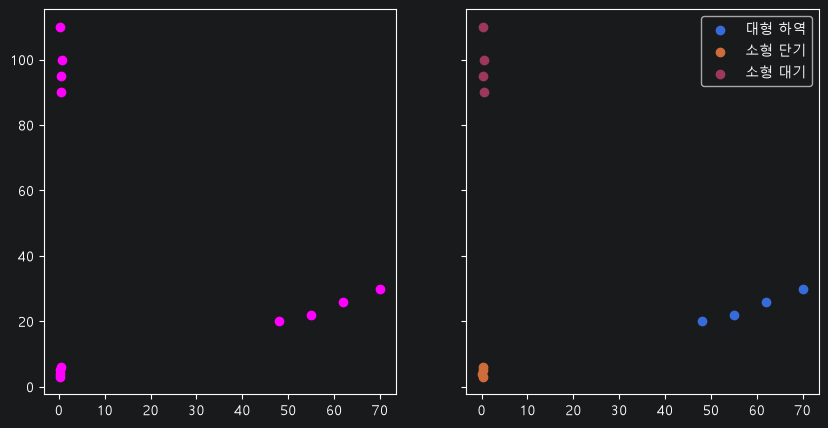

In [8]:
fig, axes = plt.subplots(1,2,figsize=(10,5),sharey=True)

axes[0].scatter(toy['총톤수'], toy['체류시간'], color= 'magenta')
# 경향만 있는 데이터이다.

for group, part in toy.groupby('군집'):
    axes[1].scatter(part['총톤수'], part['체류시간'], label=group)

axes[1].legend()
# 군집화가 된 모델이다.


fig.show()

# 좋은 군집의 조건
군집화를 하기 위한 방법은 여러가지가 있다. 확정적인 정답은 없지만 좋은 군집이 되기 위한 조건은 있다.
- 같은 군집 안의 점들은 서로서로 가까워야 된다.(응집도cohesion)
- 다른 군집끼리는 멀리 떨어져 있어야 된다.(분리도separation)

응집도는 많이 응집될수록 분리도는 확실히 분리될수록 좋은 것이다.

# 분류classification 와 군집clustering
분류는 분류할 대상/기준(정답)이 있어야 한다
군집은 정답 없이 묶어야 한다

분류는 이미 아는 구분을 자동으로 붙이는 일에 사용되는 개념이고 군집은 아직 모르는 구분을 발견하는 일에 사용된다.

- 분류: 정답 이름표가 달린 데이터를 구분짓는 것 - 지도학습으로 평가 가능
- 군집: 값만 있는 상태에서 데이터들을 모아 보는 것 - 응집과 분리로 확인

## 군집분석의 절차
1. 질문 결정
2. 변수 선택 *
3. 전처리
4. 알고리즘 및 K 설정(K-means?)
5. 해석
6. 검증 및 활용

### 변수 선택과 군집화
군집분석에서는 '비슷하다'를 기준으로 군집화를 수행하는데 어떤 변수를 기준으로 했는가에 따라서 결과가 달라질 수 있다.

몇 건의 데이터가 있는데 변수를 총톤수만 넣으며 '큰배/작은배' 체류시간만 넣으면 '오래 있는 배/ 금방 가는 배'

운영에서 구분하고 싶은 차이를 결정한 다음 변수를 설정하는 것이 중요하다. 변수 선택 자체가 분석자의 판단이 들어갔다.

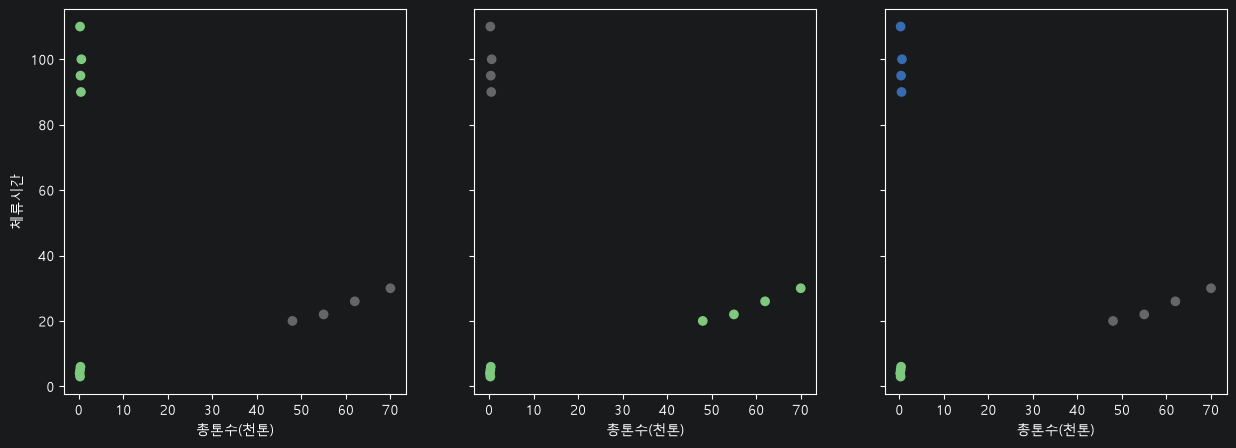

In [26]:
from sklearn.cluster import KMeans

variable_sets = {
    '총톤수':(['총톤수'],2), #k=2
    '체류시간': (['체류시간'],2), #k=2
    '총톤수+체류시간': (['총톤수','체류시간'],3) #k=3
}

fig, axes = plt.subplots(1,3,figsize=(15,5),sharey=True)

zip(axes, variable_sets.items()) # 길이(3)가 같기 때문에 zip을 해서 반복문 쓸 수 있음

for ax, (title, (col,k)) in zip(axes, variable_sets.items()):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(toy[col]) # 아까 toy에 있던 걸로 분류
    ax.scatter(toy['총톤수'],toy['체류시간'],c=labels, cmap='Accent')
    ax.set_xlabel('총톤수(천톤)')
axes[0].set_ylabel('체류시간')





plt.show()

In [12]:
toy.groupby('군집')[['총톤수','체류시간']].mean()

# 지금은 이름이 적혀 있지만 원래는 숫자만 나오니까 군집 프로필로 이름을 설정해줘야 한다.

,총톤수,체류시간
군집,,
대형 하역,58.75,24.50
소형 단기,0.30,4.50
소형 대기,0.45,98.75


In [21]:
TARGET_DATA = '입출항_집계정보'
d004 = load_dataset(TARGET_DATA)
d004 = d004[['선박종류명', '총톤수','입항일시','출항일시','적재톤수','양하톤수']]
d004
d004.shape

(272904, 6)

In [22]:
d004.info()
d004.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 272904 entries, 0 to 272903
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   선박종류명   272894 non-null  str    
 1   총톤수     272467 non-null  float64
 2   입항일시    272904 non-null  str    
 3   출항일시    272904 non-null  str    
 4   적재톤수    270645 non-null  float64
 5   양하톤수    270644 non-null  float64
dtypes: float64(3), str(3)
memory usage: 12.5 MB


,선박종류명,총톤수,입항일시,출항일시,적재톤수,양하톤수
0,풀컨테이너선,18334.0,2019-10-17 14:00,2019-10-18 14:00,6773.0,6773.0
1,LPG 운반선,3345.0,2019-10-15 19:00,2019-10-16 10:00,0.0,0.0
2,일반화물선,2398.0,2019-10-14 06:00,2019-10-14 16:00,4093.0,4093.0


In [34]:
d004['입항'] = pd.to_datetime(d004['입항일시'], format='%Y-%m-%d %H:%M', errors='coerce')
d004['출항'] = pd.to_datetime(d004['출항일시'], format='%Y-%m-%d %H:%M', errors='coerce')

In [35]:
d004.info()

<class 'pandas.DataFrame'>
RangeIndex: 272904 entries, 0 to 272903
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   선박종류명   272894 non-null  str           
 1   총톤수     272467 non-null  float64       
 2   입항일시    272904 non-null  str           
 3   출항일시    272904 non-null  str           
 4   적재톤수    270645 non-null  float64       
 5   양하톤수    270644 non-null  float64       
 6   입항      272904 non-null  datetime64[us]
 7   출항      272904 non-null  datetime64[us]
 8   체류시간    0 non-null       float64       
 9   화물톤     270644 non-null  float64       
dtypes: datetime64[us](2), float64(5), str(3)
memory usage: 20.8 MB


In [36]:
d004['체류시간'] = (d004['출항']-d004['입항']).dt.total_seconds() / 3600
d004['화물톤'] = d004['적재톤수']+d004['양하톤수']

In [37]:
rules = {
    '기간 밖 입항' : ~d004['입항'].dt.year.between(2019,2024),
    '체류 음수, 30분 미만': d004['체류시간']<0.5,
    '총톤수 0 이하, 결측': ~(d004['총톤수']>0),
    '화물톤 결측': d004['화물톤'].isna(),
    '화물톤>총톤수': d004['화물톤']>d004['총톤수']*10
}

for name, mask in rules.items():
    print(f'{name} = {mask.sum()}건')

drop = pd.concat(rules,axis=1).any(axis=1)
vessels = d004[~drop].copy()
vessels

기간 밖 입항 = 43건
체류 음수, 30분 미만 = 8116건
총톤수 0 이하, 결측 = 470건
화물톤 결측 = 2260건
화물톤>총톤수 = 1260건


,선박종류명,총톤수,입항일시,출항일시,적재톤수,양하톤수,입항,출항,체류시간,화물톤
0,풀컨테이너선,18334.0,2019-10-17 14:00,2019-10-18 14:00,6773.0,6773.0,2019-10-17 14:00:00,2019-10-18 14:00:00,24.000000,13546.0
1,LPG 운반선,3345.0,2019-10-15 19:00,2019-10-16 10:00,0.0,0.0,2019-10-15 19:00:00,2019-10-16 10:00:00,15.000000,0.0
2,일반화물선,2398.0,2019-10-14 06:00,2019-10-14 16:00,4093.0,4093.0,2019-10-14 06:00:00,2019-10-14 16:00:00,10.000000,8186.0
3,석유제품 운반선,200.0,2019-09-26 15:50,2019-10-08 05:35,0.0,0.0,2019-09-26 15:50:00,2019-10-08 05:35:00,277.750000,0.0
4,세미(혼재)컨테이너선,13682.0,2019-06-26 20:00,2019-06-27 12:00,313.0,313.0,2019-06-26 20:00:00,2019-06-27 12:00:00,16.000000,626.0
...,...,...,...,...,...,...,...,...,...,...
272897,견인용예선,49.0,2023-12-23 11:15,2023-12-27 06:45,0.0,0.0,2023-12-23 11:15:00,2023-12-27 06:45:00,91.500000,0.0
272898,기타 예선,19.0,2023-09-11 11:38,2023-09-11 12:37,0.0,0.0,2023-09-11 11:38:00,2023-09-11 12:37:00,0.983333,0.0
272899,기타 예선,19.0,2023-09-11 13:05,2023-09-19 15:25,0.0,0.0,2023-09-11 13:05:00,2023-09-19 15:25:00,194.333333,0.0
272900,기타 예선,19.0,2023-11-03 08:37,2023-12-04 08:54,0.0,0.0,2023-11-03 08:37:00,2023-12-04 08:54:00,744.283333,0.0


In [38]:
vessels.shape

(261608, 10)

In [39]:
vessels['선박종류명'].value_counts()

선박종류명
풀컨테이너선         78388
석유제품 운반선       62590
일반화물선          22392
견인용예선          19416
기타 예선          10912
산물선(벌크선)       10386
기타 유조선          8043
원양 어선           7264
여객선             7190
급유선             6318
냉동.냉장선          5617
기타선             5283
케미칼 운반선         4414
세미(혼재)컨테이너선     2971
시멘트운반선          1987
국제카페리           1829
원유운반선           1492
LPG 운반선         1309
자동차운반선           969
철강재 운반선          630
관공선              529
크루즈선             367
모래운반선            265
이.접안용 예선         207
LNG 운반선          203
압항 예선            170
군함               126
케미칼가스 운반선         95
용달선               77
폐기물 운반선           32
연근해 어선            27
수상레저기구            25
유람선               17
석탄운반선             13
준설선               12
원목운반선             12
신조선               10
화객선                9
코일전용선              4
핫코일운반선             3
예부선                2
광목운반선              1
통선                 1
기타 부선              1
Name: count, dtype: int64

In [42]:
top_vessels = vessels['선박종류명'].value_counts().head(6)
top = vessels[vessels['선박종류명'].isin(top_vessels.index)]
quartiles = top.groupby('선박종류명')[['총톤수', '체류시간', '화물톤']].quantile([0.25, 0.5, 0.75]).unstack().round(0)
quartiles

총톤수                    체류시간                  화물톤           \
            0.25     0.50     0.75  0.25  0.50   0.75    0.25     0.50   
선박종류명                                                                    
견인용예선       54.0     80.0     99.0   9.0  32.0  103.0     0.0      0.0   
기타 예선       46.0     79.0    137.0   6.0  27.0  106.0     0.0      0.0   
산물선(벌크선)  4416.0  22918.0  36300.0   7.0  13.0   35.0     0.0    400.0   
석유제품 운반선   181.0    438.0    919.0  10.0  28.0   68.0     0.0      0.0   
일반화물선     1725.0   2997.0   5549.0   7.0  18.0   49.0     0.0   1382.0   
풀컨테이너선    9522.0  17518.0  54809.0  14.0  20.0   29.0  5010.0  11951.0   

                   
             0.75  
선박종류명              
견인용예선         0.0  
기타 예선         0.0  
산물선(벌크선)  13400.0  
석유제품 운반선   1400.0  
일반화물선      4897.0  
풀컨테이너선    35480.0

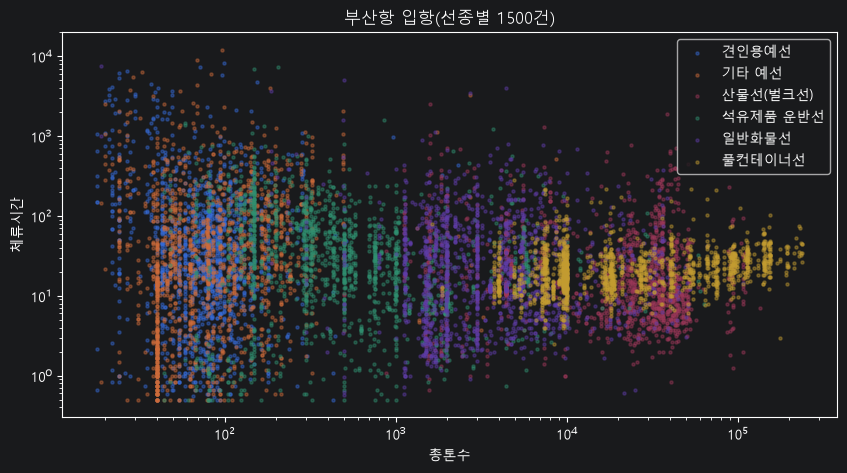

In [44]:
type_sample = top.groupby('선박종류명', group_keys=False).sample(1500, random_state=55)



fig, ax = plt.subplots(figsize=(10,5))


for name, part in type_sample.groupby('선박종류명'):
    ax.scatter(part['총톤수'], part['체류시간'], s=5, alpha=0.4, label=name)

ax.set_xscale('log') # 이걸 안 주면 꼬리가 커서 밑으로 가라앉음
ax.set_yscale('log') # 로그로 하면 10승수 표현으로 바뀌면서 퍼지게 됨

ax.set_title('부산항 입항(선종별 1500건)')
ax.set_xlabel('총톤수')
ax.set_ylabel('체류시간')
ax.legend()
plt.show() # 범례가 너무 많아..

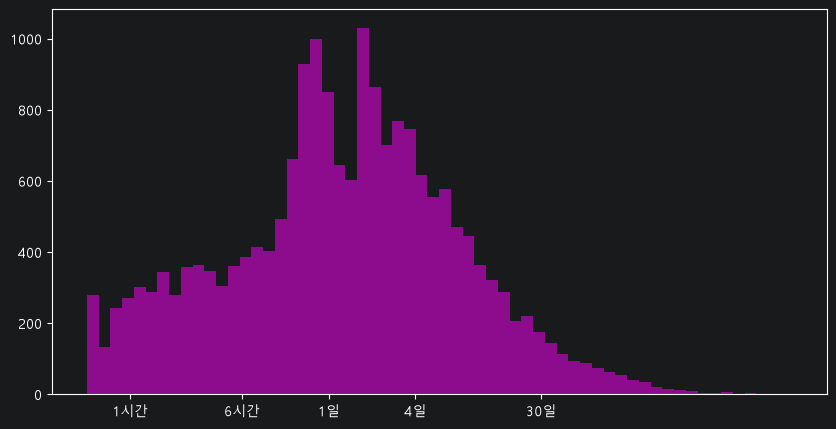

In [50]:
stay = vessels.loc[vessels['선박종류명']=='견인용예선','체류시간']
bins = [0, 6, 12, 24, 48, 96, 720]

fig, ax = plt.subplots(figsize=(10,5))

ax.hist(np.log10(stay), bins=60, color='magenta', alpha=0.5) #넘파이에서 계산해줌

ax.set_xticks(np.log10([1,6,24,96,720]),(['1시간','6시간','1일','4일','30일']))#눈금측을 알아서 조절 0은 안됨
# 쌍봉분포 - 서로 다른 무리가 여기에 섞일 수 있음
plt.show()


체류시간 구간별 비율을 확인하면 1일, 4일 초과가 양쪽 끝으로 몰려있고 가운데는 상대적으로 적다. 봉우리가 2개 식별이 되는데 이렇게 봉우리가 2개인 분포를 쌍봉 분포bimodal distribution이라고 일컫고 이는 곧 서로 다른 두 무리가 한 이름 아래

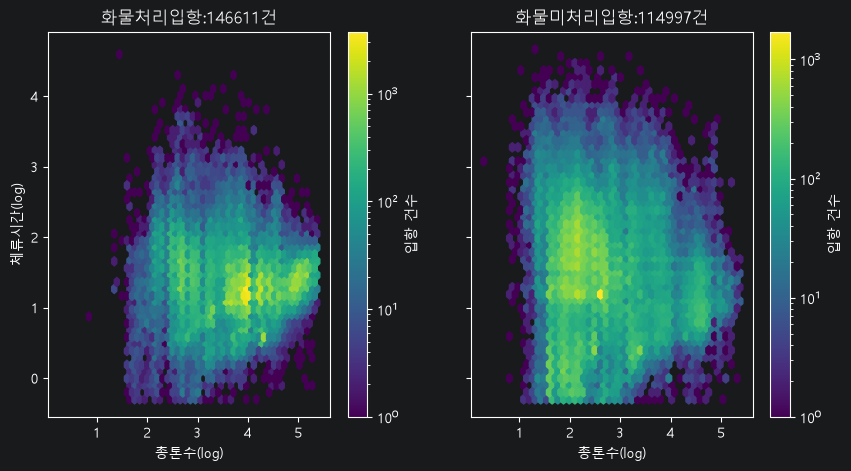

In [53]:
has_cargo = vessels['화물톤'] > 0

# 헥스코드-16진수
# 육각 밀도 그림(hexbin plot)
fig, axes = plt.subplots(1,2,figsize=(10,5),sharex=True, sharey=True)

for ax, mask, name in [ (axes[0], has_cargo, '화물처리입항'), (axes[1], ~has_cargo, '화물미처리입항')]:
    part = vessels[mask]
    hb = ax.hexbin(
        np.log10(part['총톤수']),
        np.log10(part['체류시간']),
        bins='log',
        gridsize=45, #격자 간격
    )
    ax.set_title(f'{name}:{mask.sum()}건')
    ax.set_xlabel('총톤수(log)')
    fig.colorbar(hb, ax=ax, label='입항 건수')

axes[0].set_ylabel('체류시간(log)')
plt.show() #색칠이 히트맨으로 들어감